## Resnet-50 (1)

In [ ]:
from torchvision.models import resnet50
import os
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch
import torch.nn as nn
import torch.optim as optim

In [1]:
data_path = r'C:\Users\johnp\Documents\Paul_Files\CSELEC3\Dog classification\Dogs'

preprocessPath = r'C:\Users\johnp\Documents\Paul_Files\CSELEC3\Dog classification\Preprocessed'

In [27]:
os.makedirs(preprocessPath, exist_ok=True)

In [52]:
for dogBreed in os.listdir(data_path):
    classPath = os.path.join(data_path, dogBreed)

    for dog in os.listdir(classPath):
        imagePath = os.path.join(classPath, dog)

        outputPath = os.path.join(preprocessPath, dogBreed)

        os.makedirs(outputPath, exist_ok=True)

        img = Image.open(imagePath)

        resized = img.resize((224,224))
        
        savePath = os.path.join(preprocessPath, dogBreed, f"{dog[:-4]}_Resized{dog[-4:]}")

        resized.save(savePath)


In [57]:
import os
import shutil
import random
from pathlib import Path

def train_test_split(data_dir, output_dir, test_ratio=0.2, seed=42):
    random.seed(seed)

    # Create train and test directories
    train_dir = Path(output_dir) / 'train'
    test_dir = Path(output_dir) / 'test'
    train_dir.mkdir(parents=True, exist_ok=True)
    test_dir.mkdir(parents=True, exist_ok=True)

    for class_dir in os.listdir(data_dir):
        class_path = Path(data_dir) / class_dir
        if not class_path.is_dir():
            continue

        images = list(class_path.glob('*.jpg')) + list(class_path.glob('*.png'))
        random.shuffle(images)

        split_idx = int(len(images) * (1 - test_ratio))
        train_images, test_images = images[:split_idx], images[split_idx:]

        # Create class folders in train and test directories
        (train_dir / class_dir).mkdir(parents=True, exist_ok=True)
        (test_dir / class_dir).mkdir(parents=True, exist_ok=True)

        # Copy images to respective directories
        for img in train_images:
            shutil.copy(img, train_dir / class_dir / img.name)
        for img in test_images:
            shutil.copy(img, test_dir / class_dir / img.name)

        print(f"Class '{class_dir}': {len(train_images)} train, {len(test_images)} test")

if __name__ == "__main__":
    # Change the Number only
    data_dir = r'C:\Users\johnp\Documents\Paul_Files\CSELEC3\Dog classification\Preprocessed'
    output_dir = r'C:\Users\johnp\Documents\Paul_Files\CSELEC3\Dog classification\Dataset'
    train_test_split(data_dir, output_dir, test_ratio=0.2)

Class 'Bedlington_Terrier': 40 train, 10 test
Class 'Black_and_Tan_Coonhound': 40 train, 10 test
Class 'Bluetick': 40 train, 10 test
Class 'Chihuahua': 35 train, 9 test
Class 'Ibizan_Hound': 40 train, 10 test


In [58]:
trainDir = r'C:\Users\johnp\Documents\Paul_Files\CSELEC3\Dog classification\Dataset\train'
testDir = r'C:\Users\johnp\Documents\Paul_Files\CSELEC3\Dog classification\Dataset\test'

In [165]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

valid_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

In [74]:
trainData = datasets.ImageFolder(trainDir, transform=train_transforms)
testData = datasets.ImageFolder(testDir, transform=valid_transforms)


In [94]:
trainLoader = DataLoader(trainData, batch_size=32, shuffle=True)
testLoader = DataLoader(testData, batch_size=32, shuffle=True)

numOfClass = len(trainData.classes)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


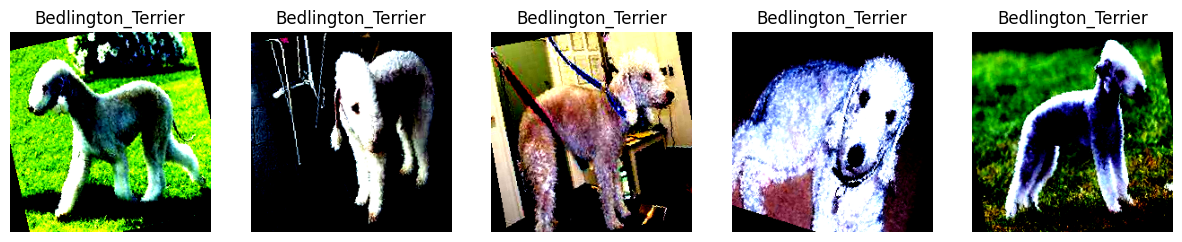

In [79]:
import matplotlib.pyplot as plt

# Pick some samples from training data
fig, axes = plt.subplots(1, 5, figsize=(15,3))
for i in range(5):
    img, label = trainData[i]
    axes[i].imshow(img.permute(1, 2, 0))  # convert to HWC for plotting
    axes[i].set_title(trainData.classes[label])
    axes[i].axis("off")
plt.show()

In [83]:
from tqdm import tqdm

def train_model(model, criterion, optimizer, num_epochs=5):
    # Move model to device (CPU or GPU)
    model.to(device)
    
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        running_loss, running_corrects = 0.0, 0

        # Wrap train_loader with tqdm to display a progress bar for each epoch
        progress_bar = tqdm(trainLoader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

        for inputs, labels in progress_bar:
            # Move data to device (GPU/CPU)
            inputs, labels = inputs.to(device), labels.to(device)

            # Reset gradients before backward pass
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(inputs)
            
            # Get predictions (class index with highest score)
            _, preds = torch.max(outputs, 1)
            
            # Compute loss
            loss = criterion(outputs, labels)

            # Backward pass (compute gradients)
            loss.backward()
            
            # Update model weights
            optimizer.step()

            # Update running totals for loss and correct predictions
            running_loss += loss.item() * inputs.size(0)  # batch loss × batch size
            running_corrects += torch.sum(preds == labels.data)

            # Update tqdm progress bar with current batch stats
            progress_bar.set_postfix({
                "Batch Loss": f"{loss.item():.4f}",
                "Correct": f"{running_corrects.item()}/{len(trainLoader.dataset)}"
            })

        # Compute average loss and accuracy for the epoch
        epoch_loss = running_loss / len(trainLoader.dataset)
        epoch_acc = running_corrects.double() / len(trainLoader.dataset)

        # Print summary for the epoch
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
    
    return model


In [84]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [85]:
model = resnet50(weights='ResNet50_Weights.IMAGENET1K_V1')
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [89]:
# Replace the final classification layer with one matching our dataset classes
model.fc = nn.Linear(model.fc.in_features, numOfClass)

# Define loss function (categorical classification -> CrossEntropy)
criterion = nn.CrossEntropyLoss()

# Define optimizer (Adam with a small learning rate)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("Training ResNet50...")
resnet = train_model(model, criterion, optimizer, num_epochs=5)

Training ResNet50...


Epoch 1/5 - Loss: 1.6085 Acc: 0.2449


Epoch 2/5 - Loss: 0.7300 Acc: 1.0000


Epoch 3/5 - Loss: 0.3547 Acc: 1.0000


Epoch 4/5 - Loss: 0.2151 Acc: 1.0000


Epoch 5/5 - Loss: 0.1108 Acc: 1.0000


In [99]:
torch.save(resnet.state_dict(), "resnet50_model.pth")

In [157]:
model = resnet50()

# Replace final layer with your number of classes (example: 3 classes)
num_classes = 5
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)

In [158]:
# Load model later (for inference/deployment)
resnet.load_state_dict(torch.load("resnet50_model.pth", map_location=device))
resnet.eval()  # set to evaluation mode


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [171]:
dataTransform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

In [178]:
# Replace with your image path
image_path = r'C:\Users\johnp\Documents\Paul_Files\CSELEC3\Dog classification\Dataset\test\Bluetick\Bluetick (21)_Resized.jpg'
img = Image.open(image_path).convert('RGB')

# Apply transform
input_tensor = dataTransform(img).unsqueeze(0)  # Add batch dimension

In [179]:
with torch.no_grad():
    outputs = model(input_tensor)
    _, predicted = torch.max(outputs, 1)

# Example: class names in order
class_names = ['Bedlington_Terrier', 'Black_and_Tan_Coonhound', 'Bluetick', 'Chihuahua', 'Ibizan_Hound']

print(f"Predicted Class: {class_names[predicted.item()]}")

Predicted Class: Bedlington_Terrier


In [155]:
import torch
from tqdm import tqdm

def evaluate_model(model, dataloader, criterion, device):
    model.eval()  # set to evaluation mode
    running_loss = 0.0
    running_corrects = 0

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double() / len(dataloader.dataset)

    print(f"Validation Loss: {epoch_loss:.4f} | Validation Accuracy: {epoch_acc:.4f}")

    return epoch_loss, epoch_acc

In [95]:
# After training
val_loss, val_acc = evaluate_model(resnet, testLoader, criterion, device)

Evaluating: 100%|██████████| 2/2 [00:02<00:00,  1.19s/it]

Validation Loss: 0.0174 | Validation Accuracy: 1.0000


In [96]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def detailed_evaluation(model, dataloader, class_names, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Classification report
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion matrix heatmap
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()


                         precision    recall  f1-score   support

     Bedlington_Terrier       1.00      1.00      1.00        10
Black_and_Tan_Coonhound       1.00      1.00      1.00        10
               Bluetick       1.00      1.00      1.00        10
              Chihuahua       1.00      1.00      1.00         9
           Ibizan_Hound       1.00      1.00      1.00        10

               accuracy                           1.00        49
              macro avg       1.00      1.00      1.00        49
           weighted avg       1.00      1.00      1.00        49



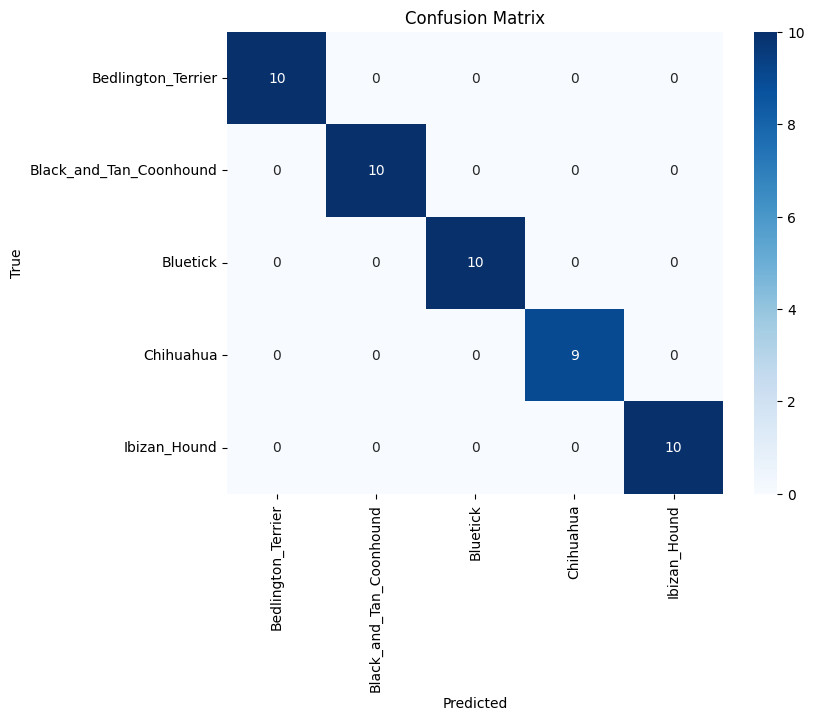

In [ ]:
detailed_evaluation(resnet, testLoader, trainData.classes,device)



## ResNet-50 (2)

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

In [ ]:
DATASET_DIR = "dataset"  # dataset/train, dataset/val
BATCH_SIZE = 16
NUM_EPOCHS = 15
LR = 1e-4
IMG_SIZE = 224
MODEL_SAVE_PATH = "resnet50_cassava.pth"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


In [ ]:
train_dir = os.path.join(DATASET_DIR, "train")
val_dir = os.path.join(DATASET_DIR, "val")

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Num classes:", num_classes)

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

In [ ]:
for param in model.parameters():
    param.requires_grad = False

# Replace final layer for your dataset classes
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(DEVICE)

In [ ]:
criterion = nn.CrossEntropyLoss()

# Only train the new fc layer
optimizer = optim.Adam(model.fc.parameters(), lr=LR)

In [ ]:
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / len(loader), correct / total

In [ ]:
@torch.no_grad()
def validate(model, loader):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Validating", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / len(loader), correct / total

In [ ]:
best_val_acc = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        checkpoint = {
            "model_state_dict": model.state_dict(),
            "class_names": class_names
        }
        torch.save(checkpoint, MODEL_SAVE_PATH)
        print(f"✅ Saved best model to {MODEL_SAVE_PATH}")

print("Training complete.")


## ResNet-50 Tensor

In [35]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [37]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    r'C:\Users\johnp\Documents\Paul_Files\CSELEC3\Dog classification\Dataset\train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    r'C:\Users\johnp\Documents\Paul_Files\CSELEC3\Dog classification\Dataset\val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 195 images belonging to 5 classes.


Found 49 images belonging to 5 classes.


In [38]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False   # freeze layers for transfer learning


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [39]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=x)


In [40]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [42]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)


Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.1949 - loss: 1.6653 - val_accuracy: 0.1633 - val_loss: 1.6116
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 974ms/step - accuracy: 0.2205 - loss: 1.6178 - val_accuracy: 0.2041 - val_loss: 1.6161
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.1897 - loss: 1.6341 - val_accuracy: 0.1837 - val_loss: 1.6273
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.1846 - loss: 1.6209 - val_accuracy: 0.2449 - val_loss: 1.6088
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.1846 - loss: 1.6086 - val_accuracy: 0.1837 - val_loss: 1.6051


In [43]:
model.save("resnet50_model.h5")

In [44]:
import tensorflow as tf

# Load the trained model
model = tf.keras.models.load_model("resnet50_model.h5")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save .tflite file
with open("resnet50_model.tflite", "wb") as f:
    f.write(tflite_model)


INFO:tensorflow:Assets written to: C:\Users\johnp\AppData\Local\Temp\tmpn9t5ph4u\assets


INFO:tensorflow:Assets written to: C:\Users\johnp\AppData\Local\Temp\tmpn9t5ph4u\assets


Saved artifact at 'C:\Users\johnp\AppData\Local\Temp\tmpn9t5ph4u'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_17')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2082969453392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2082969454352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2082969457040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2082969463568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2082969465872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2082969461264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2082969465296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2082969468752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2082969466256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2082969464912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  208

## ConvNeXt-S

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import convnext_small, ConvNeXt_Small_Weights
from tqdm import tqdm

In [ ]:
trainData = r'Dataset/train'
valData = r'Dataset/val'

In [ ]:
weights = ConvNeXt_Small_Weights.IMAGENET1K_V1

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=weights.meta["mean"],
        std=weights.meta["std"]
    )
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=weights.meta["mean"],
        std=weights.meta["std"]
    )
])


In [ ]:
train_dataset = datasets.ImageFolder(
    root=trainData,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=valData,
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

num_classes = len(train_dataset.classes)
print("Classes:", train_dataset.classes)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = convnext_small(weights=weights)
model.to(device)

In [ ]:
model.classifier = [LayerNorm2d, Flatten, Linear]

In [ ]:
model.classifier[2] = nn.Linear(
    in_features=model.classifier[2].in_features,
    out_features=num_classes
)

In [ ]:
# Optional Freeze BackBone

for param in model.features.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True
    

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)


In [ ]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.1
)

In [ ]:
# Training the Model

epochs = 20

for epoch in range(epochs):
    # ---- Training ----
    model.train()
    train_loss = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # ---- Validation ----
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = 100 * correct / total

    scheduler.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {avg_train_loss:.4f} "
        f"Val Acc: {val_acc:.2f}%"
    )


In [ ]:
# Saved the Model

torch.save(model.state_dict(), "convnext_small.pth")

In [ ]:
# Load the Model sample

model.load_state_dict(
    torch.load("convnext_small.pth", map_location=device)
)
model.eval()

In [ ]:
# Try Predicting

from PIL import Image

image = Image.open("test.jpg").convert("RGB")
image = val_transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(image)
    predicted_class = train_dataset.classes[output.argmax(1).item()]

print("Prediction:", predicted_class)

## Swin-T

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import swin_t, Swin_T_Weights
from tqdm import tqdm

In [ ]:
trainData = r'Dataset/train'
valData = r'Dataset/val'

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

In [ ]:
weights = Swin_T_Weights.IMAGENET1K_V1
# train_transforms = weights.transforms()

In [ ]:
# Optional Augmentation
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=weights.meta["mean"], std=weights.meta["std"])
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=weights.meta["mean"], std=weights.meta["std"])
])


In [ ]:
train_dataset = datasets.ImageFolder(trainData, transform=train_transforms)
val_dataset   = datasets.ImageFolder(valData, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

num_classes = len(train_dataset.classes)
print("Classes:", train_dataset.classes)


In [ ]:
model = swin_t(weights=weights)

In [ ]:
model.head

In [ ]:
model.head = nn.Linear(model.head.in_features, num_classes)
model = model.to(device)

In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.head.parameters():
    param.requires_grad = True

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.head.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [ ]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(f"""
Epoch [{epoch+1}/{epochs}]
Train Loss: {running_loss/len(train_loader):.4f}
Train Acc : {train_acc:.2f}%
Val Acc   : {val_acc:.2f}%
""")


In [ ]:
# Optional for fine tuning

# Freeze everything
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last stage
for param in model.features[4].parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in model.head.parameters():
    param.requires_grad = True

optimizer = optim.AdamW([
    {"params": model.features[4].parameters(), "lr": 1e-4},
    {"params": model.head.parameters(), "lr": 1e-3}
], weight_decay=1e-4)


In [ ]:
torch.save(model.state_dict(), "swin_t.pth")

In [ ]:
# Sample Load model

model = swin_t(weights=None)
model.head = nn.Linear(model.head.in_features, num_classes)
model.load_state_dict(torch.load("swin_t.pth"))
model.to(device)
model.eval()

## Vit-B

In [ ]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

In [ ]:
DATASET_DIR = "dataset"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")

BATCH_SIZE = 16
IMG_SIZE = 224
EPOCHS = 10
LR = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SAVE_PATH = "vitb_cassava_best.pth"
CLASS_NAMES_PATH = "class_names.txt"

In [ ]:
weights = ViT_B_16_Weights.DEFAULT

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=weights.transforms().mean, std=weights.transforms().std),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=weights.transforms().mean, std=weights.transforms().std),
])

In [ ]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Save class names
class_names = train_dataset.classes
print("Classes:", class_names)
with open(CLASS_NAMES_PATH, "w") as f:
    for name in class_names:
        f.write(name + "\n")


In [ ]:
model = vit_b_16(weights=weights)

# Replace head for custom classes
num_features = model.heads.head.in_features
model.heads.head = nn.Linear(num_features, len(class_names))

model = model.to(DEVICE)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR)

In [ ]:
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def validate(model, loader):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation", leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


In [ ]:
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, SAVE_PATH)
        print(f"✅ Saved best model: {SAVE_PATH}")

print("\nTraining finished.")
print("Best Val Accuracy:", best_acc)


In [ ]:
model.load_state_dict(torch.load("vit_base.pth"))
model.eval()


## EfficientNet-v2

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
from tqdm import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

In [ ]:
weights = EfficientNet_V2_S_Weights.DEFAULT
img_transforms = weights.transforms()

In [ ]:
data_dir = "Dataset"
batch_size = 32


train_dataset = datasets.ImageFolder(
    root=f"{data_dir}/train",
    transform=img_transforms
)


val_dataset = datasets.ImageFolder(
    root=f"{data_dir}/val",
    transform=img_transforms
)


train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)


num_classes = len(train_dataset.classes)
print("Classes:", train_dataset.classes)

In [ ]:
model = efficientnet_v2_s(weights=weights)

In [ ]:
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)


model = model.to(device)

In [ ]:
for param in model.features.parameters():
    param.requires_grad = False

In [ ]:
trainable = [n for n, p in model.named_parameters() if p.requires_grad]
print(trainable)

In [ ]:
criterion = nn.CrossEntropyLoss()


optimizer = optim.Adam(
model.classifier.parameters(),
lr=1e-3
)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0, 0, 0


    for images, labels in tqdm(loader):
        images, labels = images.to(device), labels.to(device)


        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()


        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)


    return running_loss / total, correct / total




def validate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0, 0, 0


    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)


            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)


    return running_loss / total, correct / total

In [ ]:
epochs_stage1 = 10


for epoch in range(epochs_stage1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)


print(
    f"Epoch [{epoch+1}/{epochs_stage1}] "
    f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}"
)

In [ ]:
# Fine Tune

for param in model.features[-2:].parameters():
    param.requires_grad = True

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)


epochs_stage2 = 10


for epoch in range(epochs_stage2):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion
    )
    val_loss, val_acc = validate(
        model, val_loader, criterion
    )


print(
    f"[FT] Epoch [{epoch+1}/{epochs_stage2}] "
    f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}"
)

In [ ]:
# Save Model

torch.save({
    "model_state": model.state_dict(),
    "class_names": train_dataset.classes
}, "efficientnetv2_custom.pth")

In [ ]:
# Predicting

from PIL import Image

model.eval()

img = Image.open("sample.jpg").convert("RGB")
img = img_transforms(img).unsqueeze(0).to(device)


with torch.no_grad():
    output = model(img)
    pred = torch.argmax(output, dim=1).item()

print("Predicted class:", train_dataset.classes[pred])

## MobileNet-v3

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import MobileNet_V3_Large_Weights, mobilenet_v3_large
from torch.utils.data import DataLoader
import os


In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [ ]:
train_dir = "dataset/train"
val_dir = "dataset/val"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = mobilenet_v3_large(pretrained=MobileNet_V3_Large_Weights.IMAGENET1K_V1)
model = model.to(device)


In [ ]:
# Replace final layer
model.classifier[3] = nn.Linear(
    in_features=model.classifier[3].in_features,
    out_features=num_classes
)

model = model.to(device)


In [ ]:
for param in model.features.parameters():
    param.requires_grad = False


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)


In [ ]:
num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {running_loss:.4f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Val Acc: {val_acc:.2f}%")


In [ ]:
torch.save(model.state_dict(), "mobilenetv3_cassava.pth")


In [ ]:
model = mobilenet_v3_large(weights=None)
model.classifier[3] = nn.Linear(
    model.classifier[3].in_features, 4
)

model.load_state_dict(torch.load("mobilenetv3_cassava.pth"))
model.eval()
model.to(device)


In [ ]:
from PIL import Image

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = val_transforms(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)

    return class_names[predicted.item()]

print(predict_image("sample_leaf.jpg"))


## AlexNet

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import numpy as np


In [ ]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}


In [ ]:
data_dir = "dataset"

image_datasets = {
    x: datasets.ImageFolder(root=f"{data_dir}/{x}",
                            transform=data_transforms[x])
    for x in ['train', 'val']
}

dataloaders = {
    x: DataLoader(image_datasets[x],
                  batch_size=32,
                  shuffle=True,
                  num_workers=2)
    for x in ['train', 'val']
}

class_names = image_datasets['train'].classes
num_classes = len(class_names)

print("Classes:", class_names)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.alexnet(pretrained=True)


In [ ]:
model.classifier[6] = nn.Linear(
    in_features=4096,
    out_features=num_classes
)

model = model.to(device)


In [ ]:
for param in model.features.parameters():
    param.requires_grad = False


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=0.0001
)


In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    print("-" * 30)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(image_datasets[phase])
        epoch_acc = running_corrects.double() / len(image_datasets[phase])

        print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")


In [ ]:
torch.save(model.state_dict(), "alexnet_cassava.pth")

In [ ]:
model.load_state_dict(torch.load("alexnet_cassava.pth"))
model.eval()


In [ ]:
from PIL import Image

def predict_image(image_path, model, class_names):
    image = Image.open(image_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)

    return class_names[predicted.item()]


In [ ]:
result = predict_image("test_leaf.jpg", model, class_names)
print("Predicted class:", result)


In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b7, EfficientNet_B7_Weights
from tqdm import tqdm

In [34]:
IMG_SIZE = 600
BATCH_SIZE = 8
EPOCHS = 5
LR = 1e-4
DATA_DIR = r'C:\Users\johnp\Documents\Paul_Files\CSELEC3\Dog classification\Dataset'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", device)

DEVICE: cpu


In [35]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [36]:
train_set = datasets.ImageFolder(f"{DATA_DIR}/train", transform=train_transform)
val_set   = datasets.ImageFolder(f"{DATA_DIR}/val", transform=val_transform)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

num_classes = len(train_set.classes)
print("NUMBER OF CLASSES:", num_classes)

NUMBER OF CLASSES: 5


In [37]:
weights = EfficientNet_B7_Weights.DEFAULT
model = efficientnet_b7(weights=weights)

# Replace the classifier
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

model = model.to(device)

In [38]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [39]:
def train_one_epoch(epoch):
    model.train()
    total_loss = 0
    correct = 0

    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Training", ncols=100)

    for images, labels in progress:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

        progress.set_postfix({"Loss": loss.item()})

    accuracy = correct / len(train_set)
    print(f"Train Loss: {total_loss/len(train_loader):.4f} | Train Acc: {accuracy:.4f}")


In [40]:
def validate():
    model.eval()
    total_loss = 0
    correct = 0

    progress = tqdm(val_loader, desc="Validating", ncols=100)

    with torch.no_grad():
        for images, labels in progress:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

            progress.set_postfix({"Loss": loss.item()})

    accuracy = correct / len(val_set)
    print(f"VAL Loss: {total_loss/len(val_loader):.4f} | VAL Acc: {accuracy:.4f}")



In [41]:
for epoch in range(EPOCHS):
    train_one_epoch(epoch)
    validate()

Epoch 1/5 Training: 100%|█████████████████████████████| 25/25 [1:06:08<00:00, 158.75s/it, Loss=1.75]


Train Loss: 1.3370 | Train Acc: 0.7077


Validating: 100%|██████████████████████████████████████████| 7/7 [00:41<00:00,  5.92s/it, Loss=1.08]


VAL Loss: 1.0808 | VAL Acc: 1.0000


Epoch 2/5 Training: 100%|█████████████████████████████| 25/25 [1:13:26<00:00, 176.24s/it, Loss=1.82]


...

VAL Loss: 0.0894 | VAL Acc: 0.9796


Epoch 5/5 Training: 100%|███████████████████████████| 25/25 [1:19:25<00:00, 190.64s/it, Loss=0.0757]


Train Loss: 0.1244 | Train Acc: 0.9692


Validating: 100%|███████████████████████████████████████| 7/7 [00:42<00:00,  6.02s/it, Loss=0.00192]

VAL Loss: 0.0552 | VAL Acc: 1.0000


In [42]:
torch.save(model.state_dict(), "efficientnet_b7_model.pth")
print("Model saved!")

Model saved!


In [43]:
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
            (1): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormAct

In [9]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b7, EfficientNet_B7_Weights

model_path = r'./efficientnet_b7_model.pth'
num_classes = 5

model1 = efficientnet_b7(weights=None)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model1 = efficientnet_b7(weights=None)  # do NOT load pretrained ImageNet weights

# Replace classifier to match your training setup
in_features = model1.classifier[1].in_features
model1.classifier[1] = nn.Linear(in_features, num_classes)

model1.to(device)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
            (1): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormAct

In [12]:
model1.load_state_dict(torch.load(model_path, map_location=device))
model1.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [22]:
from PIL import Image
from torchvision import transforms

IMG_SIZE = 600

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

img = Image.open(r'C:\Users\johnp\Documents\Paul_Files\CSELEC3\Dog classification\Dataset\train\Chihuahua\Chihuahua (17)_Resized.jpg').convert("RGB")
img_tensor = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    output = model1(img_tensor)
    pred = output.argmax(1).item()

print("Predicted class index:", pred)

Predicted class index: 3


In [24]:
class_names= ['Bedlington_Terrier', 'Black_and_Tan_Coonhound', 'Bluetick', 'Chihuahua', 'Ibizan_Hound']

with torch.no_grad():
    output = model1(img_tensor)
    probs = torch.softmax(output, dim=1)
    confidence, pred_class = torch.max(probs, dim=1)

confidence = confidence.item()

if confidence < 0.40:   # threshold (you can tune it)
    print("Unknown Breed")
else:
    print("Predicted:", class_names[pred_class], "| Confidence:", confidence)


Predicted: Chihuahua | Confidence: 0.9842280149459839


In [32]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB7
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [34]:
tf.__version__

'2.20.0'

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    r'path\to\train',
    target_size=(600, 600),
    batch_size=16,
    class_mode='categorical',
    color_mode='rgb'
)

val_generator = val_datagen.flow_from_directory(
    r'path\to\val',
    target_size=(600, 600),
    batch_size=16,
    class_mode='categorical',
    color_mode='rgb'
)


Found 195 images belonging to 5 classes.
Found 49 images belonging to 5 classes.


In [33]:
base_model = EfficientNetB7(
    weights='imagenet',
    include_top=False,
    input_shape=(600, 600, 3)
)
base_model.trainable = False

ValueError: Shape mismatch in layer #1 (named stem_conv)for weight stem_conv/kernel. Weight expects shape (3, 3, 1, 64). Received saved weight with shape (3, 3, 3, 64)

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)  # single neuron for binary classification

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1
)   

## ShuffleNet-V2

In [ ]:
import torch
import torch.nn as nn
from torchvision.models.shufflenetv2 import shufflenet_v2_x1_5, ShuffleNet_V2_X1_5_Weights
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch.optim as optim
from tqdm import tqdm


In [6]:
num_classes = 5

In [7]:
model = shufflenet_v2_x1_5(weights=ShuffleNet_V2_X1_5_Weights)

c:\Users\johnp\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ShuffleNet_V2_X1_5_Weights.IMAGENET1K_V1`. You can also use `weights=ShuffleNet_V2_X1_5_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [8]:
# Replace final classification layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
# Data transform

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [ ]:
# Load Dataset

train_path = r'C:\Users\johnp\Documents\Paul_Files\CSELEC3\Dog classification\Dataset\train'
val_path = r'C:\Users\johnp\Documents\Paul_Files\CSELEC3\Dog classification\Dataset\val'

train_data = ImageFolder(train_path, transform=train_transforms)
val_data   = ImageFolder(val_path, transform=val_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)

class_names = train_data.classes
print(class_names)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

In [ ]:
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    print("Validation Accuracy:", round(correct / total * 100, 2), "%")


In [ ]:
# Save the Model
torch.save(model.state_dict(), "shufflenet_v2_1_5_custom.pth")

In [ ]:
# Check Prediction

from PIL import Image

img = Image.open("test.jpg").convert("RGB")
img = val_transforms(img)
img = img.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(img)
    pred = torch.argmax(output, dim=1)

print("Predicted:", class_names[pred.item()])


## YOLOv8x

In [16]:
from ultralytics import YOLO

In [17]:
model = YOLO("yolov8x.pt")

In [ ]:
dataset_yaml = ""

In [ ]:
result = model.train(data=dataset_yaml, epochs=5, imgsz=640)

## Converter to TorchScript

In [ ]:
import torch
from torchvision import models

num_classes = 5  # your dataset

# Load pre-trained model
model = models.efficientnet_b7(weights=None)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, num_classes)

# Load your custom weights
model.load_state_dict(torch.load("efficientnet_b7_model.pth", map_location="cpu"), strict=False)
model.eval()

# Dummy input for tracing (correct input size)
example = torch.randn(1, 3, 600, 600)

# Trace the model instead of scripting
traced_model = torch.jit.trace(model, example)

# Save for mobile
traced_model.save("efficientnet_b7_dog_mobile.pt")


In [ ]:
import torch
from torchvision.models import efficientnet_b7 

# Load your model
num_classes = 5  # your dataset
model = efficientnet_b7()
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, num_classes)

# Load weights
model.load_state_dict(torch.load("efficientnet_b7_model.pth", map_location="cpu"))
model.eval()

# Dummy input (batch size 1, EfficientNetB7 expects 600×600)
dummy_input = torch.randn(1, 3, 600, 600)

torch.onnx.export(
    model,
    dummy_input,
    "efficientnetb7.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=12,
    dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}},
)


In [5]:
from ultralytics import YOLO

In [6]:
model = YOLO("yolov8x.pt")

In [20]:
result = model.predict("pitbull.jpg", imgsz=640, conf=0.5)


image 1/1 c:\Users\johnp\Documents\Paul_Files\CSELEC3\Thesis\Models\pitbull.jpg: 640x640 1 dog, 994.9ms
Speed: 34.8ms preprocess, 994.9ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
result[0].show()

In [11]:
type(result)

list

In [ ]:
for r in result:
    boxes = r.boxes  # Access the Boxes object containing bounding box data
    # Further processing of boxes, e.g., print coordinates or save to a file
    for box in boxes:
        print(f"Bounding Box: {box.xyxy}, Class: {box.cls}, Confidence: {box.conf}")
        print(box.orig_shape)

In [28]:
from PIL import Image

result = model("pitbull.jpg", imgsz=640, conf=0.5)[0]        # run YOLO
annotated = result.plot()       # returns numpy array
annotated_pil = Image.fromarray(annotated)


print(annotated_pil)




image 1/1 c:\Users\johnp\Documents\Paul_Files\CSELEC3\Thesis\Models\pitbull.jpg: 640x640 1 dog, 994.3ms
Speed: 3.8ms preprocess, 994.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
<PIL.Image.Image image mode=RGB size=800x800 at 0x23EB0E53170>


## Crete YAML File

In [ ]:
# Python function to automatically create data.yaml config file
# 1. Reads "classes.txt" file to get list of class names
# 2. Creates data dictionary with correct paths to folders, number of classes, and names of classes
# 3. Writes data in YAML format to data.yaml

import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read class.txt to get class names
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # Create data dictionary
  data = {
      'path': '/content/data',
      'train': 'train/images',
      'val': 'validation/images',
      'nc': number_of_classes,
      'names': classes
  }

  # Write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

# Define path to classes.txt and run function
path_to_classes_txt = '/content/custom_data/classes.txt'
path_to_data_yaml = '/content/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)